# **The Antarctic Baseline: Quantifying Environmental Dynamics in Near Zero-Radiance Regimes** 
## *Part 1 : Polynomial Optimization of Surface Albedo Dynamics Using Gradient Descent*

---


## *Introduction*

The Antarctic cryosphere plays an important role in regulating the Earth’s energy balance, with surface albedo acting as one of the key controls on how much incoming solar radiation is reflected back into the atmosphere. Even small reductions in surface reflectivity can increase localized heat absorption and contribute to changes in polar ice stability over time.

This study focuses on the Larsen C Ice Shelf, a highly sensitive Antarctic region that has undergone significant environmental and structural change in recent decades. Using MODIS-derived environmental indicators extracted through Google Earth Engine over the 2015-2025 observational period, the notebook investigates how surface temperature and solar geometry relate to changing albedo behavior across the ice shelf.

---

## **Problem Statement**

>Understanding how Antarctic surface albedo changes under varying thermal and solar conditions is important for studying large-scale cryospheric instability and energy balance behavior. This study investigates the non-linear decline of surface reflectance across the Larsen C Ice Shelf between 2015 and 2025 using reduced satellite-derived environmental indicators and a custom Degree-2 Polynomial Regression model optimized through Gradient Descent.

## *Study Region* 
**Region of Interest**

Larsen C Ice Shelf, Antarctica 

**Approximate Coordinates:** 
- Latitude: 67.5°S 
- Longitude: 64.5°W 

This study focuses on the Larsen C Ice Shelf in Antarctica, one of the largest remaining ice shelves within the Antarctic cryosphere. 
The cryosphere refers to the frozen regions of the Earth, including glaciers, sea ice, ice sheets, and polar ice shelves, which play an important role in regulating global energy balance and climate behavior.

The Larsen C Ice Shelf was selected because it represents a highly sensitive cryospheric environment undergoing measurable structural and thermodynamic instability while remaining largely free from direct anthropogenic urban interference. This makes it useful as a near-zero-radiance environmental baseline for studying subtle environmental signal behavior. 

---

In [2]:
import ee 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error

In [3]:
ee.Authenticate()

True

In [ ]:
ee.Initialize(project='astrotourism-darksky')

In [ ]:
region=ee.Geometry.Rectangle([-66.0, -68.5,-63.0, -66.5])
start_date='2015-01-01'
end_date='2025-12-31'
modis_lst=(ee.ImageCollection('MODIS/061/MOD11A1').filterDate(start_date, end_date).select('LST_Day_1km'))
modis_albedo=(ee.ImageCollection('MODIS/061/MCD43A3').filterDate(start_date, end_date).select('Albedo_WSA_shortwave'))
modis_solar=(ee.ImageCollection('MODIS/061/MOD09GA').filterDate(start_date, end_date).select('SolarZenith'))
def extract_daily_observation(image):
    date=image.date().format('YYYY-MM-dd')
    lst_image=modis_lst.filterDate(image.date(),image.date().advance(1, 'day')).first()
    albedo_image=modis_albedo.filterDate(image.date(),image.date().advance(1, 'day')).first()
    solar_image=modis_solar.filterDate(image.date(),image.date().advance(1, 'day')).first()
    surface_temp=ee.Number(lst_image.reduceRegion(reducer=ee.Reducer.mean(),geometry=region,scale=1000,maxPixels=1e9).get('LST_Day_1km'))
    surface_albedo=ee.Number(albedo_image.reduceRegion(reducer=ee.Reducer.mean(),geometry=region,scale=500,maxPixels=1e9).get('Albedo_WSA_shortwave'))
    solar_zenith=ee.Number(solar_image.reduceRegion(reducer=ee.Reducer.mean(),geometry=region,scale=1000,maxPixels=1e9).get('SolarZenith'))
    return ee.Feature(None, {
        'date': date,
        'surface_temp': surface_temp,
        'solar_zenith': solar_zenith,
        'surface_albedo': surface_albedo
    })
dataset=modis_lst.map(extract_daily_observation)
records=dataset.getInfo()['features']
rows=[]
for record in records:
    properties=record['properties']
    rows.append({
        'date': properties.get('date'),
        'surface_temp': properties.get('surface_temp'),
        'solar_zenith': properties.get('solar_zenith'),
        'surface_albedo': properties.get('surface_albedo')
    })
df=pd.DataFrame(rows)
df['surface_temp']=(df['surface_temp'] * 0.02 - 273.15)
df['solar_zenith']=(df['solar_zenith'] * 0.01)
df['surface_albedo']=(df['surface_albedo'] * 0.001)
df=df.replace([np.inf, -np.inf], np.nan)
df=df.dropna()
df=df.reset_index(drop=True)
print(df.head())
print(df.shape)
print(df.describe())

         date  surface_temp  solar_zenith  surface_albedo
0  2015-01-01     -4.490099     53.772216        0.733728
1  2015-01-02     -3.446475     54.129804        0.732435
2  2015-01-03     -3.397931     51.971582        0.731124
3  2015-01-04     -5.659448     57.299931        0.733065
4  2015-01-05    -19.234894     56.139842        0.732165
(2700, 4)
       surface_temp  solar_zenith  surface_albedo
count   2700.000000   2700.000000     2700.000000
mean     -21.290619     68.316284        0.708251
std        9.915108     10.094106        0.049326
min      -59.593810     51.186503        0.380821
25%      -28.326302     59.044074        0.675104
50%      -20.284837     67.165502        0.719075
75%      -13.500388     78.136491        0.745669
max        0.091557     94.162618        0.808750


## *Data Source*

The environmental variables used in this study were extracted from publicly available satellite-derived planetary datasets hosted on the Google Earth Engine (GEE) platform. Instead of downloading and processing large raster datasets locally, Google Earth Engine was used only to aggregate spatial observations into lightweight tabular environmental measurements.
The variables were sourced from the following MODIS products:

- *surface_temp* : Extracted from the MODIS Land Surface Temperature product (`MOD11A1`)
- *solar_zenith* : Extracted from the MODIS Surface Reflectance product (`MOD09GA`)
- *surface_albedo* : Extracted from the MODIS BRDF/Albedo product (`MCD43A3`)

---

## *Understanding the Extracted Variables*

After reducing the MODIS satellite observations over the Larsen C Ice Shelf into a local analytical dataset, we obtained a compact three-variable environmental matrix designed for lightweight machine learning experimentation. Each column in the dataset represents a physically meaningful planetary indicator associated with cryospheric energy balance and surface behavior.

---

## *Dataset Structure*
| Column | Type | Role in Study | Description |
|---|---|---|---|
| `surface_temp` | Quantitative (Continuous) | Feature ($X_1$) | Represents the average land surface temperature derived from MODIS thermal observations. Values are converted into degrees Celsius and act as a thermal forcing indicator across the ice shelf. |
| `solar_zenith` | Quantitative (Continuous) | Feature ($X_2$) | Represents the solar zenith angle, describing the position of the Sun relative to the surface. This variable captures seasonal illumination geometry and influences incoming shortwave radiation. |
| `surface_albedo` | Quantitative (Continuous) | Target Variable ($y$) | Represents the shortwave surface reflectance of the Antarctic ice surface. Higher values indicate stronger reflectivity, while lower values suggest increased absorption of solar energy. |

Final Training Loss: 0.0010051372241527193
Test MSE: 0.000850405075027369
Learned Weights:
[ 0.69926494  0.00164953 -0.03735959  0.00549865  0.00283284  0.00469506]


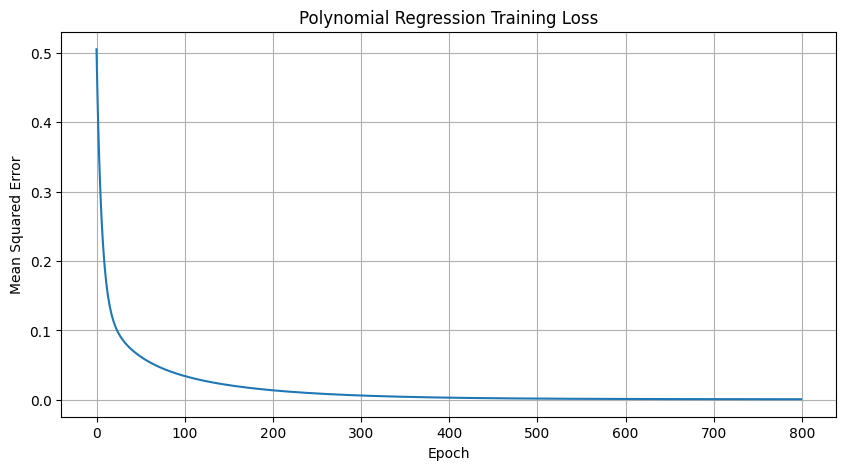

In [ ]:
X=df[['surface_temp', 'solar_zenith']].values
y=df['surface_albedo'].values
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=726)
train_mean=X_train.mean(axis=0)
train_std=X_train.std(axis=0)
X_train_scaled=(X_train - train_mean)/train_std
X_test_scaled=(X_test-train_mean)/train_std
X_train_poly=np.column_stack([
    np.ones(X_train_scaled.shape[0]),
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    X_train_scaled[:, 0] ** 2,
    X_train_scaled[:, 1] ** 2,
    X_train_scaled[:, 0] * X_train_scaled[:, 1]])
X_test_poly=np.column_stack([
    np.ones(X_test_scaled.shape[0]),
    X_test_scaled[:, 0],
    X_test_scaled[:, 1],
    X_test_scaled[:, 0] ** 2,
    X_test_scaled[:, 1] ** 2,
    X_test_scaled[:, 0] * X_test_scaled[:, 1]])
weights=np.zeros(X_train_poly.shape[1])
learning_rate=0.01
epochs=800
loss_history=[]
n=len(y_train)
for epoch in range(epochs):
    predictions=X_train_poly @ weights
    errors=predictions-y_train
    mse=np.mean(errors ** 2)
    gradient=(2/n) * (X_train_poly.T @ errors)
    weights=weights-learning_rate*gradient
    loss_history.append(mse)
test_predictions=X_test_poly @ weights
test_mse=np.mean((test_predictions-y_test)**2)
print("Final Training Loss:", loss_history[-1])
print("Test MSE:", test_mse)
print("Learned Weights:")
print(weights)
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Polynomial Regression Training Loss")
plt.grid(True)
plt.show()

## *Understanding the Model Results*

After training the Degree-2 Polynomial Regression model using Gradient Descent, the optimization converged successfully across 800 epochs. The final training and testing errors remained very close to each other:
- Training MSE= 0.0010051372241527193
- Testing MSE= 0.000850405075027369

The training and testing errors remain relatively close, indicating that the model generalized well to unseen observations rather than simply memorizing the training dataset. The low testing error suggests that the learned regression surface captured meaningful relationships between the environmental variables and Antarctic surface albedo.

---

## *What does the Learning Curve Tell Us*

The training loss curve dropped sharply during the early epochs and then gradually flattened into a stable low-error region.
This behavior is important because it shows that:
- the learning rate was large enough for efficient optimization
- the gradients remained stable throughout training
- the model converged smoothly without oscillation or divergence

Most of the reduction in error occurred during the first 100 epochs, after which the optimization continued at a slower rate as the parameter estimates were refined. Beyond approximately 400 epochs, the curve entered a low-error region where improvements became progressively smaller, suggesting that the model was approaching convergence.

---

## *Interpreting the Polynomial Regression Equation*

The model learned the following parameter vector:

$$\theta=[ 0.69926494,\,0.00164953,\,-0.03735959,\,0.00549865,\,0.00283284,\,0.00469506]$$

These weights correspond to the following Degree-2 polynomial structure:

$$\hat{y}=\theta_0+\theta_1 T+\theta_2 Z+\theta_3 T^2+\theta_4 Z^2+\theta_5 TZ$$

where:

- (T) represents scaled surface temperature,
- (Z) represents scaled solar zenith angle,
- ($\hat{y}$) represents predicted surface albedo.

---

## *Baseline Albedo State*

$$\theta_0=0.69926494$$

The bias term represents the baseline reflectivity level of the Larsen C Ice Shelf when the standardized predictors are centered around their average values. This value is close to the overall mean albedo observed within the dataset, suggesting that the optimization converged toward a physically meaningful environmental baseline.

---

## *Effect of Surface Temperature*

$$\theta_1=0.00164953$$

The temperature coefficient is positive but relatively small in magnitude. This suggests that, after accounting for solar illumination geometry and non-linear effects, surface temperature contributed only a limited amount to the overall variability in surface albedo.

The small coefficient indicates that temperature alone was not a variable influencing reflectance changes within the study period. Instead, its influence appears to be more dependent on interactions with other environmental conditions.

---

## *Effect of Solar Zenith Angle*

$$\theta_2=-0.03735959$$

This is the first-order coefficient in the model. The negative value suggests that changes in solar illumination geometry strongly influence observed surface reflectance across the ice shelf. In polar environments, the angle of incoming sunlight affects how radiation interacts with snow and ice surfaces. As the solar zenith coefficient is much larger in magnitude than the temperature coefficient, the model suggests that radiative geometry contributed more strongly to observed albedo variability during the 2015–2025 observational period.

---

## *Non-Linear Temperature Behavior*

$$\theta_3=0.00549865$$

The positive quadratic temperature term introduces curvature into the regression surface. This indicates that the relationship between temperature and albedo is not purely linear and changes gradually across different environmental states. The presence of this coefficient supports the decision to use Polynomial Regression rather than a simple linear model.

---

## *Non-Linear Solar Geometry Behavior*

$$\theta_4=0.00283284$$

The positive quadratic solar zenith term indicates that the influence of illumination geometry is not purely linear. Instead, the effect changes across different angular conditions, introducing curvature into the regression surface. This suggests that surface albedo responds differently under varying solar angles and supports the use of Polynomial Regression rather than a simple linear model.

---

## *Interaction Between Temperature and Solar Geometry*

$$\theta_5=0.00469506$$

The interaction term demonstrates that surface temperature and solar geometry do not operate independently. Instead, their combined influence contributes to observed changes in surface albedo. Although the coefficient is modest in magnitude, it suggests that the effect of one environmental variable depends partly on the state of the other, highlighting the interconnected nature of Antarctic surface processes.

---

## *Comparing Actual vs Predicted Albedo*

After training the Polynomial Regression model,the next step is to compare the predicted albedo values against the real observed values from the test dataset.

This helps us check whether the regression model is actually capturing the environmental relationship between:
- surface temperature
- solar geometry
- Antarctic surface reflectance
If the predictions closely follow the observed values, it suggests that the model has learned meaningful patterns from the dataset.

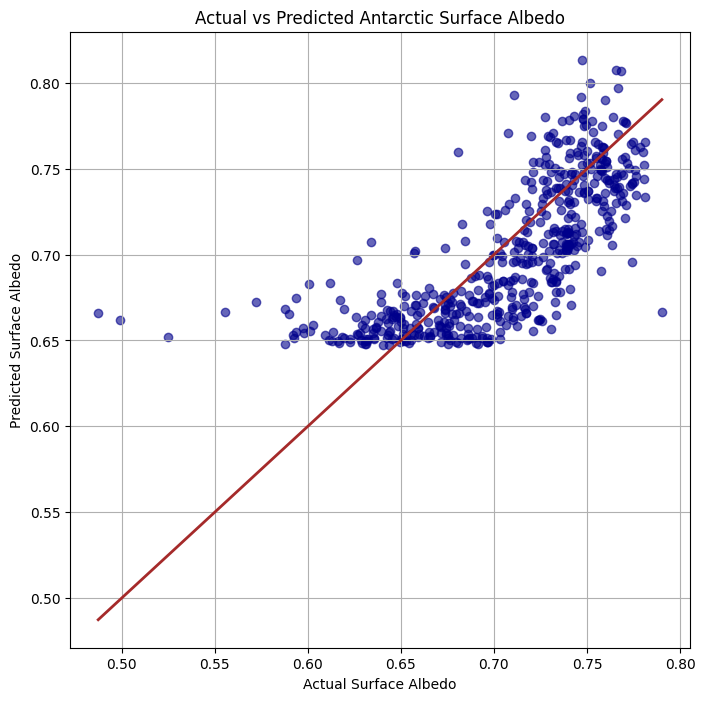

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test,test_predictions,alpha=0.6,color='darkblue')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],linewidth=2,color='brown')
plt.xlabel("Actual Surface Albedo")
plt.ylabel("Predicted Surface Albedo")
plt.title("Actual vs Predicted Antarctic Surface Albedo")
plt.grid(True)
plt.show()

## *Interpretation of the Actual vs Predicted Plot*

The scatter plot compares the observed Antarctic surface albedo values derived from MODIS observations with the values predicted by the Degree-2 Polynomial Regression model. Each point represents a single observation from the test dataset.

Points located near the red diagonal line indicate accurate predictions, since the predicted and observed albedo values are nearly identical. Most observations are concentrated within the high-albedo range (approximately 0.70-0.80), where the model follows the general trend of the data reasonably well. This suggests that the model successfully captures the dominant reflectance behavior associated with stable ice-covered conditions across the Larsen C Ice Shelf.

As observed albedo decreases into the mid-range region (0.60-0.70), the spread around the diagonal line becomes larger, indicating increased prediction uncertainty and greater environmental variability. The most important pattern appears for low-albedo observations below approximately 0.60. Instead of following the observed decline, the predictions flatten near an albedo value of about 0.65, creating an apparent lower prediction boundary. This behavior indicates that the polynomial regression model smooths extreme observations toward the overall mean of the dataset and struggles to represent rare low-reflectivity events accurately. So, the model reproduces the dominant high-albedo state of the Larsen C Ice Shelf but underestimates the magnitude of uncommon low-albedo conditions. This limitation suggests that a single global polynomial function may be insufficient for capturing localized environmental thresholds and extreme surface melt behavior.

## *Residual Error Analysis*

After comparing the actual and predicted albedo values,we examine the residual errors produced by the regression model.
Residuals represent the difference between the observed and predicted values:
$$\text{Residual}=y_{actual}-y_{predicted}$$
This helps us check whether the prediction errors are randomly distributed or whether the model shows systematic bias under certain environmental conditions.

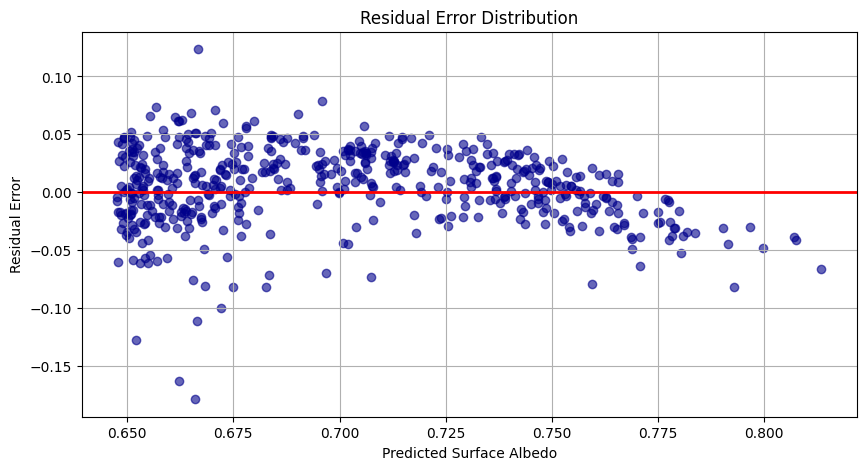

In [ ]:
residuals=y_test-test_predictions
plt.figure(figsize=(10, 5))
plt.scatter(test_predictions,residuals,alpha=0.6,color='darkblue')
plt.axhline(y=0,linewidth=2,color='red')
plt.xlabel("Predicted Surface Albedo")
plt.ylabel("Residual Error")
plt.title("Residual Error Distribution")
plt.grid(True)
plt.show()

## *Interpretation of the Residual Scatter Plot*

For higher predicted albedo values (approximately 0.72-0.80), the residuals remain tightly clustered around the zero line with relatively small vertical spread. This indicates stable prediction performance and low error variance under the dominant high-albedo conditions observed across the Larsen C Ice Shelf.

As predicted albedo decreases, the residual spread becomes noticeably larger and less symmetrical around zero. This increase in variance suggests that the model becomes less reliable under more variable environmental conditions.

The most important pattern occurs near a predicted albedo value of approximately 0.65, where the predictions appear to reach a lower boundary. At this point, several large negative residuals emerge, extending to nearly -0.15. Since

$$
\text{Residual} = y_{actual} - y_{predicted},
$$

these large negative residuals indicate cases where the model substantially overestimated surface albedo.

This behavior suggests that the polynomial regression model struggles to represent rare low-albedo events and instead pulls predictions toward the dominant mean state of the dataset. As a result, extreme reflectivity drops are not well observed.
The residual structure indicates that the model performs consistently under typical high-reflectivity conditions but loses accuracy when taken with uncommon low-albedo observations, highlighting a key limitation of using a single global polynomial function to describe complex environmental behavior.

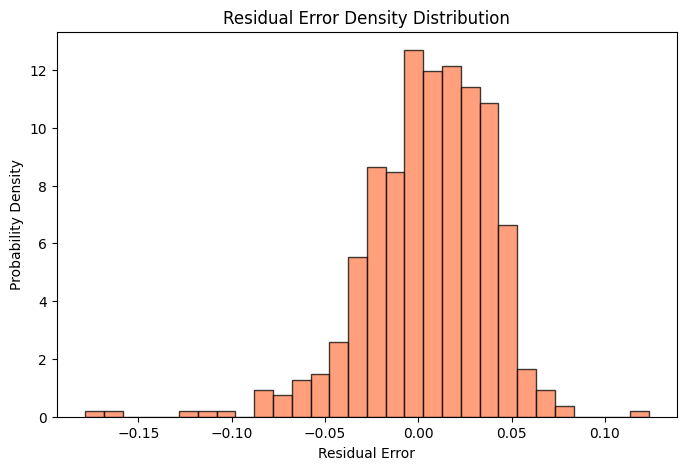

In [ ]:
residuals=y_test-test_predictions
plt.figure(figsize=(8, 5))
plt.hist(residuals,bins=30,density=True,alpha=0.75,color='coral', edgecolor='black')
plt.xlabel("Residual Error")
plt.ylabel("Probability Density")
plt.title("Residual Error Density Distribution")
plt.show()

## *Interpretation of Residual Error density distribution*

The residual error density distribution shows how prediction errors are distributed across all observations in the test dataset. The histogram is displayed as a probability density, the total area under the distribution equals one, allowing the overall shape of the error distribution to be evaluated independently of sample size.

Most of the density is concentrated within a narrow range around zero (approximately -0.05 to 0.05), with the highest peak occurring near zero residual error. This indicates that the majority of predictions were close to the observed surface albedo values, suggesting good overall model accuracy.

The distribution is not perfectly symmetric. While the positive residuals decline relatively quickly, the negative side contains a longer tail extending to approximately -0.18. These larger negative residuals correspond to observations where the model substantially overestimated albedo.

The presence of this elongated negative tail suggests that although the polynomial regression model performs well for typical environmental conditions, it struggles to capture a small number of rare low-albedo events. These observations contribute disproportionately to the overall prediction error and highlight the model's tendency to smooth extreme environmental behavior.

The density histogram indicates that prediction errors are generally small and centered near zero, while also revealing a systematic limitation in representing uncommon low-reflectivity conditions across the Larsen C Ice Shelf.

---

In [ ]:
df.to_csv("larsen_c_cleaned_data.csv", index=False)

## *Limitations*

Although the Polynomial Regression model captured the dominant reflectance behavior across the Larsen C Ice Shelf, several limitations remain.

The study used only a small set of environmental variables:

* surface temperature
* solar zenith angle
* surface albedo

Important cryospheric factors such as snow properties, cloud cover, surface melt intensity, wind conditions, and broader atmospheric variability were not included in the analysis.

The residuals also revealed reduced model performance during rare low-albedo conditions. While predictions remained stable for the dominant high-reflectivity regime, the model systematically underestimated the magnitude of extreme reflectance declines and tended to pull predictions toward the overall dataset mean. This behavior suggests that a single global polynomial function may not fully capture localized environmental thresholds.

In addition, the dataset was reduced to aggregated tabular observations. Although this lightweight approach greatly simplifies computation and model development, it removes fine-scale spatial information that may influence surface behavior across the ice shelf.

Finally, the regression model identifies statistical relationships between environmental variables and surface albedo but **does not represent a full physical climate, energy balance, or ice-sheet simulation framework.**


---


## *Conclusion*

This study developed a lightweight Earth Observation workflow to investigate Antarctic surface albedo variability across the Larsen C Ice Shelf using MODIS-derived environmental indicators extracted through Google Earth Engine.

A Degree-2 Polynomial Regression model optimized using Gradient Descent successfully captured the dominant relationship between surface temperature, solar geometry, and surface reflectance. The optimization converged smoothly, and the relatively small difference between training and testing error indicated stable performance on unseen observations.

The model reproduced the dominant high-albedo state of the ice shelf with reasonable accuracy. However,the analyses revealed that predictive performance decreased during uncommon low-albedo conditions, where the model tended to underestimate the magnitude of extreme reflectance declines. These patterns suggest that environmental behavior becomes increasingly complex outside the dominant ice-covered regime.

The results demonstrate that reduced-dimensional Earth Observation variables contain sufficient statistical structure to model large-scale Antarctic reflectance behavior using lightweight machine learning methods. At the same time, the limitations identified in the residual and prediction analyses motivate the exploration of more flexible non-linear approaches capable of capturing localized environmental thresholds and rare cryospheric events.

*This observation forms the basis for Part 2, where tree-based machine learning models are evaluated as an alternative framework for modeling Antarctic surface albedo variability.*

---

---